In [1]:
!pip install torch torchvision opencv-python matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 2.8 MB/s eta 0:00:02
   ------- -------------------------------- 0.8/4.3 MB 3.1 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.3 MB 1.4 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.3 MB 1.4 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.3 MB 1.4 MB/s eta 0:00:03
   ------------------- -------------------- 2.1/4.3 MB 1.6 MB/s eta 0:00:02
   ------------------------ --------------- 2.6/4.3 MB 1.7 MB/s eta 0:00:01
   -------------------------- ------------- 2.9/4.3 MB 1.7 MB/s eta 0:00:01
   ------------------------------------ --- 3.9/4.3 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 2.0 MB/s  0:00:02
   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\ridat\appdata\local\temp\pip-req-build-_aus8stz
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36875 sha256=36b0570ef66bf32b22d7f0fc2a2d67fcb693324fd947c504f7beb964d0f59f65
  Stored in directory: C:\Users\ridat\AppData\Local\Temp\pip-ephem-wheel-cache-8y2roly7\wheels\29\82\ff\04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\ridat\AppData\Local\Temp\pip-req-build-_aus8stz'

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

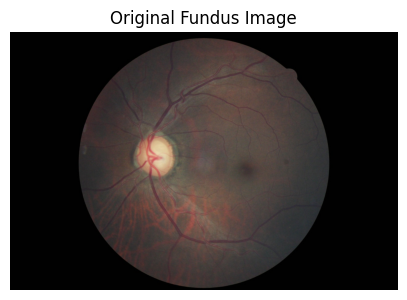

In [5]:
# Change path to your image
image_path = "retina.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Original Fundus Image")
plt.axis("off")


In [6]:
sam_checkpoint = "sam_vit_h.pth"  # download & place in same folder
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(image)


FileNotFoundError: [Errno 2] No such file or directory: 'sam_vit_h.pth'

NameError: name 'predictor' is not defined

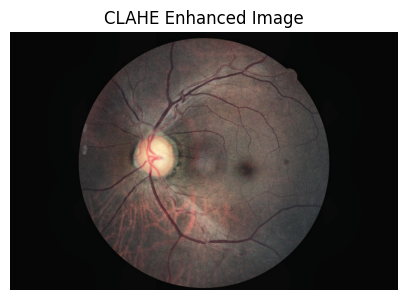

In [7]:
lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l = clahe.apply(l)

image_clahe = cv2.merge((l,a,b))
image_clahe = cv2.cvtColor(image_clahe, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image_clahe)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

predictor.set_image(image_clahe)


In [8]:
# Example RNFL points (change according to image)
input_points = np.array([
    [320, 240],
    [350, 260],
    [380, 280]
])

input_labels = np.array([1, 1, 1])  # foreground points


In [9]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


NameError: name 'predictor' is not defined

NameError: name 'best_mask' is not defined

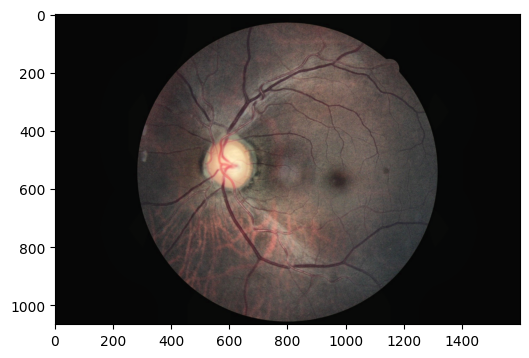

In [10]:
plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(best_mask, alpha=0.5)
plt.scatter(input_points[:,0], input_points[:,1], c='red', s=40)
plt.title("SAM RNFL Segmentation")
plt.axis("off")
plt.show()


In [11]:
# x1, y1, x2, y2 (adjust)
input_box = np.array([200, 150, 450, 420])

masks, scores, _ = predictor.predict(
    box=input_box,
    multimask_output=True
)

mask_box = masks[np.argmax(scores)]

plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(mask_box, alpha=0.5)
plt.title("SAM Box-based Segmentation")
plt.axis("off")


NameError: name 'predictor' is not defined

(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

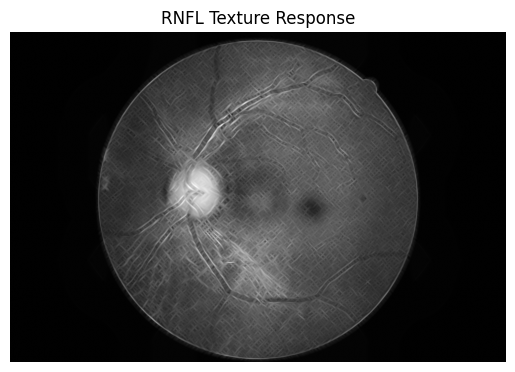

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2GRAY)

kernels = []
for theta in np.arange(0, np.pi, np.pi/4):
    kernel = cv2.getGaborKernel(
        ksize=(21,21),
        sigma=4.0,
        theta=theta,
        lambd=10.0,
        gamma=0.5,
        psi=0
    )
    kernels.append(kernel)

gabor_response = np.zeros_like(gray, dtype=np.float32)

for k in kernels:
    gabor_response = np.maximum(
        gabor_response,
        cv2.filter2D(gray, cv2.CV_32F, k)
    )

plt.imshow(gabor_response, cmap='gray')
plt.title("RNFL Texture Response")
plt.axis("off")


In [13]:
ys, xs = np.where(rnfl_candidates > 0)

# sample points (reduce count)
idx = np.random.choice(len(xs), size=20, replace=False)

sam_points = np.column_stack((xs[idx], ys[idx]))
sam_labels = np.ones(len(sam_points))



NameError: name 'rnfl_candidates' is not defined

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_labels,
    multimask_output=True
)

rnfl_mask = masks[np.argmax(scores)]


In [14]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
rnfl_mask = cv2.morphologyEx(rnfl_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)


NameError: name 'rnfl_mask' is not defined

NameError: name 'rnfl_mask' is not defined

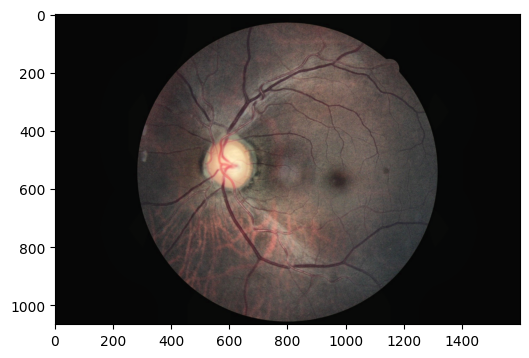

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(rnfl_mask, alpha=0.5)
plt.scatter(sam_points[:,0], sam_points[:,1], c='red', s=10)
plt.title("Final RNFL Segmentation (Auto + SAM)")
plt.axis("off")


(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

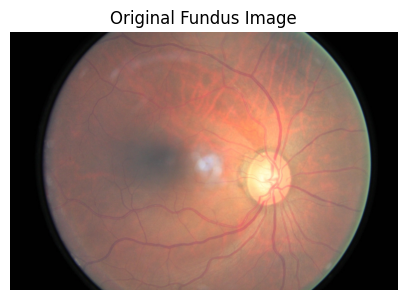

In [16]:
image_path = "retina1.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Original Fundus Image")
plt.axis("off")


In [19]:
sam_checkpoint = "sam_vit_h.pth"  # download & place in same folder
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(image)

FileNotFoundError: [Errno 2] No such file or directory: 'sam_vit_h.pth'

NameError: name 'predictor' is not defined

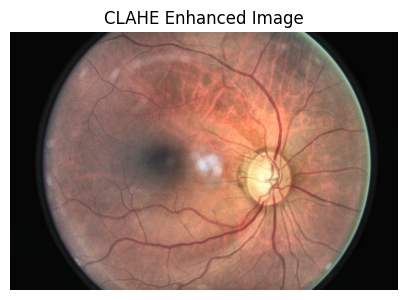

In [20]:
lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l = clahe.apply(l)

image_clahe = cv2.merge((l,a,b))
image_clahe = cv2.cvtColor(image_clahe, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image_clahe)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

predictor.set_image(image_clahe)


In [21]:
# Example RNFL points (change according to image)
input_points = np.array([
    [320, 240],
    [350, 260],
    [380, 280]
])

input_labels = np.array([1, 1, 1])  # foreground points


In [22]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]

NameError: name 'predictor' is not defined

NameError: name 'best_mask' is not defined

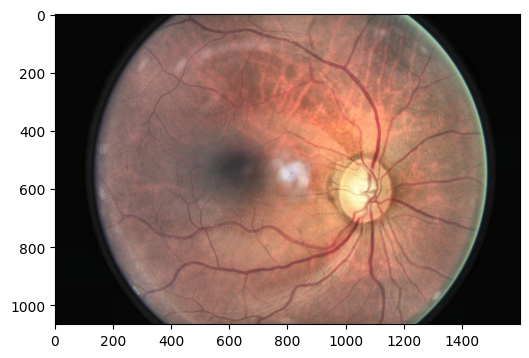

In [23]:
plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(best_mask, alpha=0.5)
plt.scatter(input_points[:,0], input_points[:,1], c='red', s=40)
plt.title("SAM RNFL Segmentation")
plt.axis("off")
plt.show()

In [24]:
# x1, y1, x2, y2 (adjust)
input_box = np.array([200, 150, 450, 420])

masks, scores, _ = predictor.predict(
    box=input_box,
    multimask_output=True
)

mask_box = masks[np.argmax(scores)]

plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(mask_box, alpha=0.5)
plt.title("SAM Box-based Segmentation")
plt.axis("off")


NameError: name 'predictor' is not defined

(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

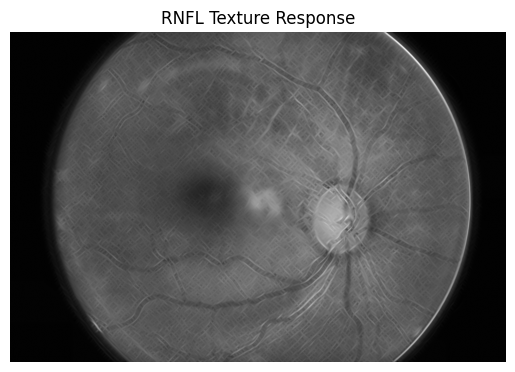

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2GRAY)

kernels = []
for theta in np.arange(0, np.pi, np.pi/4):
    kernel = cv2.getGaborKernel(
        ksize=(21,21),
        sigma=4.0,
        theta=theta,
        lambd=10.0,
        gamma=0.5,
        psi=0
    )
    kernels.append(kernel)

gabor_response = np.zeros_like(gray, dtype=np.float32)

for k in kernels:
    gabor_response = np.maximum(
        gabor_response,
        cv2.filter2D(gray, cv2.CV_32F, k)
    )

plt.imshow(gabor_response, cmap='gray')
plt.title("RNFL Texture Response")
plt.axis("off")


In [26]:
ys, xs = np.where(rnfl_candidates > 0)

# sample points (reduce count)
idx = np.random.choice(len(xs), size=20, replace=False)

sam_points = np.column_stack((xs[idx], ys[idx]))
sam_labels = np.ones(len(sam_points))

NameError: name 'rnfl_candidates' is not defined

In [27]:
masks, scores, _ = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_labels,
    multimask_output=True
)

rnfl_mask = masks[np.argmax(scores)]

NameError: name 'predictor' is not defined

In [28]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
rnfl_mask = cv2.morphologyEx(rnfl_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

NameError: name 'rnfl_mask' is not defined

NameError: name 'rnfl_mask' is not defined

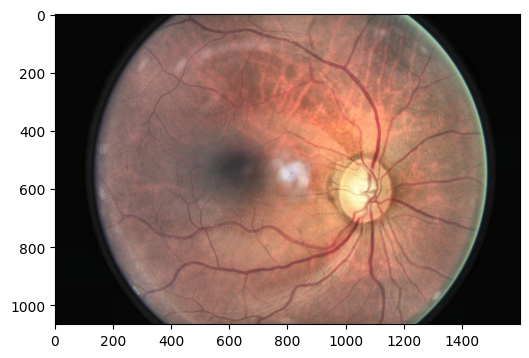

In [29]:
plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(rnfl_mask, alpha=0.5)
plt.scatter(sam_points[:,0], sam_points[:,1], c='red', s=10)
plt.title("Final RNFL Segmentation (Auto + SAM)")
plt.axis("off")


In [39]:
from skimage.morphology import skeletonize

binary = rnfl_mask > 0
skeleton = skeletonize(binary)

plt.figure(figsize=(5,5))
plt.imshow(skeleton, cmap='gray')
plt.title("RNFL Skeleton")
plt.axis("off")


NameError: name 'rnfl_mask' is not defined

In [42]:
sam_checkpoint = "sam_vit_h.pth"


In [43]:
sam_checkpoint = r"C:\Users\YourName\Downloads\sam_vit_h.pth"


In [44]:
import os
print(os.path.exists(sam_checkpoint))


False


In [45]:
import os
print(os.getcwd())



C:\Users\ridat\OneDrive\Desktop\Fundus


In [48]:
import os
print(os.path.exists("sam_vit_h.pth"))


False


In [49]:
from segment_anything import sam_model_registry, SamPredictor
import torch
import os

# ----- EXACT FOLDER YOU GAVE -----
sam_checkpoint = r"C:\Users\ridat\OneDrive\Desktop\Fundus\sam_vit_h.pth"

# safety check
print("Checkpoint exists:", os.path.exists(sam_checkpoint))

model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

# use your preprocessed image
predictor.set_image(image_clahe)


Checkpoint exists: False


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ridat\\OneDrive\\Desktop\\Fundus\\sam_vit_h.pth'

In [50]:
import os
os.listdir(r"C:\Users\ridat\OneDrive\Desktop\Fundus")


['.ipynb_checkpoints',
 'dec_3.ipynb',
 'dec_8.ipynb',
 'mean_zero_dce_output.png',
 'retina.jpg',
 'retina1.jpg',
 'retina2.jpg',
 'retina3.jpg',
 'retina4.jpg',
 'SAM.ipynb']

In [52]:
import os
print(os.getcwd())


C:\Users\ridat\OneDrive\Desktop\Fundus


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2GRAY)

kernels = []
for theta in np.arange(0, np.pi, np.pi/4):
    kernel = cv2.getGaborKernel(
        ksize=(21,21),
        sigma=4.0,
        theta=theta,
        lambd=10.0,
        gamma=0.5,
        psi=0
    )
    kernels.append(kernel)

gabor_response = np.zeros_like(gray, dtype=np.float32)

for k in kernels:
    gabor_response = np.maximum(
        gabor_response,
        cv2.filter2D(gray, cv2.CV_32F, k)
    )

plt.imshow(gabor_response, cmap='gray')
plt.title("RNFL Texture Response")
plt.axis("off")


NameError: name 'image_clahe' is not defined